In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
salary_df = pd.read_csv("data/salary_data.csv")
salary_df = salary_df.loc[:, ~salary_df.columns.str.startswith("Unnamed")]

goal_df = pd.read_csv("data/city_goal_costs.csv")

combined_df = salary_df.merge(goal_df, on="City", how="left")
print("salary_df:", salary_df.shape)
print("goal_df:", goal_df.shape)
print("combined_df:", combined_df.shape)
combined_df.info()
combined_df.head()

salary_df: (100, 5)
goal_df: (100, 5)
combined_df: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    1000 non-null   int64 
 1   City                   1000 non-null   object
 2   Education              1000 non-null   object
 3   Job_Role               1000 non-null   object
 4   Monthly_Salary         1000 non-null   int64 
 5   Area_Type              1000 non-null   object
 6   Marriage_Cost_Current  1000 non-null   int64 
 7   Car_Cost_Current       1000 non-null   int64 
 8   Home_Cost_Current      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Age,City,Education,Job_Role,Monthly_Salary,Area_Type,Marriage_Cost_Current,Car_Cost_Current,Home_Cost_Current
0,24,Hyderabad,MBA,Web Developer,40000,Central,740000,1100000,6800000
1,24,Hyderabad,MBA,Web Developer,40000,North,690000,1030000,6400000
2,24,Hyderabad,MBA,Web Developer,40000,South,700000,1050000,6500000
3,24,Hyderabad,MBA,Web Developer,40000,East,670000,1010000,6200000
4,24,Hyderabad,MBA,Web Developer,40000,West,710000,1070000,6600000


In [3]:
PLAIN_CAT = ["City", "Education", "Job_Role"]
PLAIN_NUM = ["Age"]

ENRICHED_SALARY_CAT = ["City", "Education", "Job_Role", "Area_Type"]
ENRICHED_SALARY_NUM = ["Age", "Marriage_Cost_Current", "Car_Cost_Current", "Home_Cost_Current"]

COST_CAT = ["City", "Education", "Job_Role", "Area_Type"]
COST_NUM = {
    "Marriage_Cost_Current": ["Age", "Monthly_Salary", "Car_Cost_Current", "Home_Cost_Current"],
    "Car_Cost_Current": ["Age", "Monthly_Salary", "Marriage_Cost_Current", "Home_Cost_Current"],
    "Home_Cost_Current": ["Age", "Monthly_Salary", "Marriage_Cost_Current", "Car_Cost_Current"],
}

plain_train, plain_test = train_test_split(salary_df, test_size=0.2, random_state=42)
combined_train, combined_test = train_test_split(combined_df, test_size=0.2, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def make_estimator(cat_cols, num_cols, model):
    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])
    pipeline = Pipeline([("prep", preprocessor), ("model", model)])
    return TransformedTargetRegressor(regressor=pipeline, transformer=StandardScaler())

def evaluate(name, model, train_df, test_df, cat_cols, num_cols, target_col, results, fitted):
    X_train = train_df[cat_cols + num_cols]
    X_test = test_df[cat_cols + num_cols]
    y_train = train_df[target_col]
    y_test = test_df[target_col]
    est = make_estimator(cat_cols, num_cols, model)
    cv_scores = cross_val_score(est, X_train, y_train, cv=cv, scoring="r2")
    est.fit(X_train, y_train)
    preds = est.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {"CV_R2_Mean": cv_scores.mean(), "Test_R2": r2, "Test_MAE": mae, "Test_RMSE": rmse}
    fitted[name] = est
    print(name, results[name])
    return est

def get_models():
    return {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0, random_state=42),
        "Lasso Regression": Lasso(alpha=1.0, random_state=42),
        "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
        "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42),
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
        "Support Vector Regressor": SVR(kernel="rbf"),
        "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42),
    }

In [4]:
plain_results = {}
plain_fitted = {}

In [5]:
evaluate("Linear Regression", LinearRegression(), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Linear Regression {'CV_R2_Mean': -1.1893417354633153e+22, 'Test_R2': 0.8674363429706328, 'Test_MAE': 8597.889539095508, 'Test_RMSE': 9759.643081392303}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      LinearRegression())]),
                           transformer=StandardScaler())

In [6]:
evaluate("Ridge Regression", Ridge(alpha=1.0, random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Ridge Regression

 {'CV_R2_Mean': 0.8828880687522528, 'Test_R2': 0.8794121295450564, 'Test_MAE': 7770.7846991172, 'Test_RMSE': 9308.367262217067}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      Ridge(random_state=42))]),
                           transformer=StandardScaler())

In [7]:
evaluate("Lasso Regression", Lasso(alpha=1.0, random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Lasso Regression {'CV_R2_Mean': -0.10410512094846096, 'Test_R2': -0.011907164304776119, 'Test_MAE': 21542.5, 'Test_RMSE': 26964.478949165696}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      Lasso(random_state=42))]),
                           transformer=StandardScaler())

In [8]:
evaluate("ElasticNet", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

ElasticNet {'CV_R2_Mean': 0.40430935357008024, 'Test_R2': 0.4328965404723979, 'Test_MAE': 15324.023167846311, 'Test_RMSE': 20186.11976125474}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      ElasticNet(random_state=42))]),
                           transformer=StandardScaler())

In [9]:
evaluate("Decision Tree", DecisionTreeRegressor(random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Decision Tree {'CV_R2_Mean': 0.7806118354110675, 'Test_R2': 0.8467699566126557, 'Test_MAE': 8100.0, 'Test_RMSE': 10492.85471165974}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      DecisionTreeRegressor(random_state=42))]),
                           transformer=StandardScaler())

In [10]:
evaluate("Random Forest", RandomForestRegressor(n_estimators=200, random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Random Forest {'CV_R2_Mean': 0.8636547541489665, 'Test_R2': 0.8533487270842103, 'Test_MAE': 8050.500000000009, 'Test_RMSE': 10265.133827671227}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      RandomForestRegressor(n_estimators=200,
                                                                            random_state=42))]),
                           transformer=StandardScaler())

In [11]:
evaluate("Extra Trees", ExtraTreesRegressor(n_estimators=200, random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Extra Trees {'CV_R2_Mean': 0.8439453668727385, 'Test_R2': 0.8421190855603992, 'Test_MAE': 7876.250000000009, 'Test_RMSE': 10650.905067176229}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      ExtraTreesRegressor(n_estimators=200,
                                                                          random_state=42))]),
                           transformer=StandardScaler())

In [12]:
evaluate("AdaBoost", AdaBoostRegressor(random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

AdaBoost {'CV_R2_Mean': 0.8505946453887565, 'Test_R2': 0.8571131516880666, 'Test_MAE': 7597.709023003141, 'Test_RMSE': 10132.528307409397}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      AdaBoostRegressor(random_state=42))]),
                           transformer=StandardScaler())

In [13]:
evaluate("Gradient Boosting", GradientBoostingRegressor(random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Gradient Boosting {'CV_R2_Mean': 0.8736703294562652, 'Test_R2': 0.8431112049946241, 'Test_MAE': 8478.537389762292, 'Test_RMSE': 10617.387327079354}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      GradientBoostingRegressor(random_state=42))]),
                           transformer=StandardScaler())

In [14]:
evaluate("Hist Gradient Boosting", HistGradientBoostingRegressor(random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

D:\Webskitters Projects\p9\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Webskitters Projects\p9\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\dibya\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dibya\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\dibya\AppData\Local\Programs\

Hist Gradient Boosting {'CV_R2_Mean': 0.7769311578885316, 'Test_R2': 0.7499911428980394, 'Test_MAE': 10313.24689261857, 'Test_RMSE': 13402.919050390816}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      HistGradientBoostingRegressor(random_state=42))]),
                           transformer=StandardScaler())

In [15]:
evaluate("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=5), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

K-Nearest Neighbors {'CV_R2_Mean': 0.8122036606316222, 'Test_R2': 0.7810911899683728, 'Test_MAE': 9680.0, 'Test_RMSE': 12541.61074184652}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      KNeighborsRegressor())]),
                           transformer=StandardScaler())

In [16]:
evaluate("Support Vector Regressor", SVR(kernel="rbf"), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Support Vector Regressor {'CV_R2_Mean': 0.8625545052310262, 'Test_R2': 0.7996661396929605, 'Test_MAE': 9084.602559328909, 'Test_RMSE': 11997.724276368675}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model', SVR())]),
                           transformer=StandardScaler())

In [17]:
evaluate("Neural Network (MLP)", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42), plain_train, plain_test, PLAIN_CAT, PLAIN_NUM, "Monthly_Salary", plain_results, plain_fitted)

Neural Network (MLP) {'CV_R2_Mean': 0.8334291635170559, 'Test_R2': 0.8470586888261931, 'Test_MAE': 8413.55046447873, 'Test_RMSE': 10482.964178343718}


TransformedTargetRegressor(regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('cat',
                                                                                       OneHotEncoder(handle_unknown='ignore',
                                                                                                     sparse_output=False),
                                                                                       ['City',
                                                                                        'Education',
                                                                                        'Job_Role']),
                                                                                      ('num',
                                                                                       StandardScaler(),
                                                                                       ['Age'])])),
                                                     ('model',
                                                      MLPRegressor(hidden_layer_sizes=(64,
                                                                                       32),
                                                                   max_iter=2000,
                                                                   random_state=42))]),
                           transformer=StandardScaler())

In [18]:
plain_results_df = pd.DataFrame(plain_results).T.sort_values("Test_R2", ascending=False)
plain_results_df

,CV_R2_Mean,Test_R2,Test_MAE,Test_RMSE
Ridge Regression,8.828881e-01,0.879412,7770.784699,9308.367262
Linear Regression,-1.189342e+22,0.867436,8597.889539,9759.643081
AdaBoost,8.505946e-01,0.857113,7597.709023,10132.528307
Random Forest,8.636548e-01,0.853349,8050.500000,10265.133828
Neural Network (MLP),8.334292e-01,0.847059,8413.550464,10482.964178
Decision Tree,7.806118e-01,0.846770,8100.000000,10492.854712
Gradient Boosting,8.736703e-01,0.843111,8478.537390,10617.387327
Extra Trees,8.439454e-01,0.842119,7876.250000,10650.905067
Support Vector Regressor,8.625545e-01,0.799666,9084.602559,11997.724276
K-Nearest Neighbors,8.122037e-01,0.781091,9680.000000,12541.610742


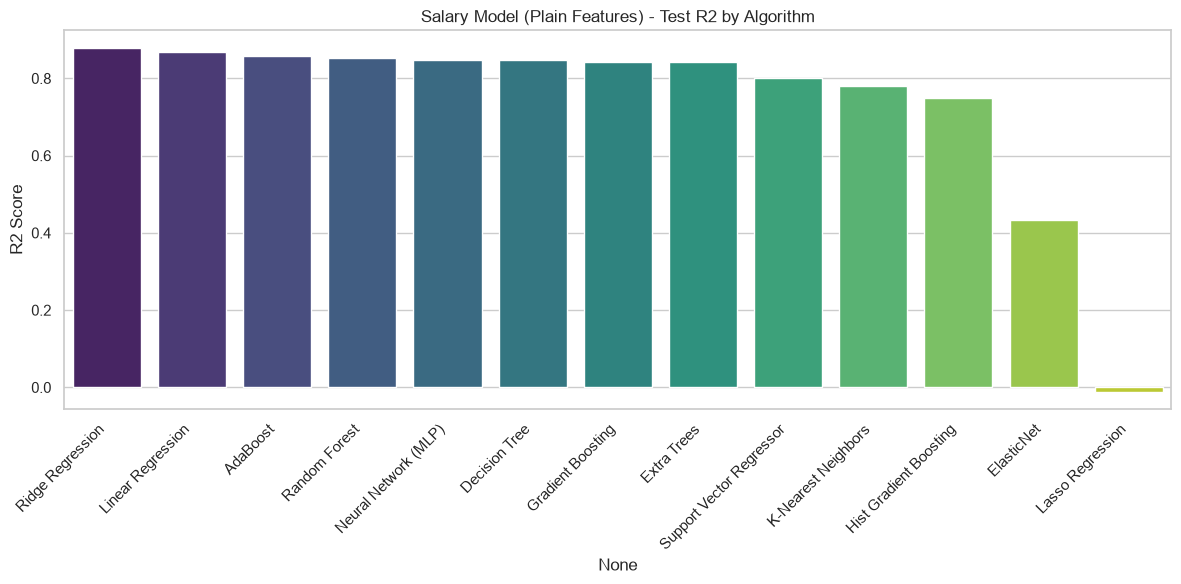

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x=plain_results_df.index, y=plain_results_df["Test_R2"], hue=plain_results_df.index, palette="viridis", legend=False)
plt.title("Salary Model (Plain Features) - Test R2 by Algorithm")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

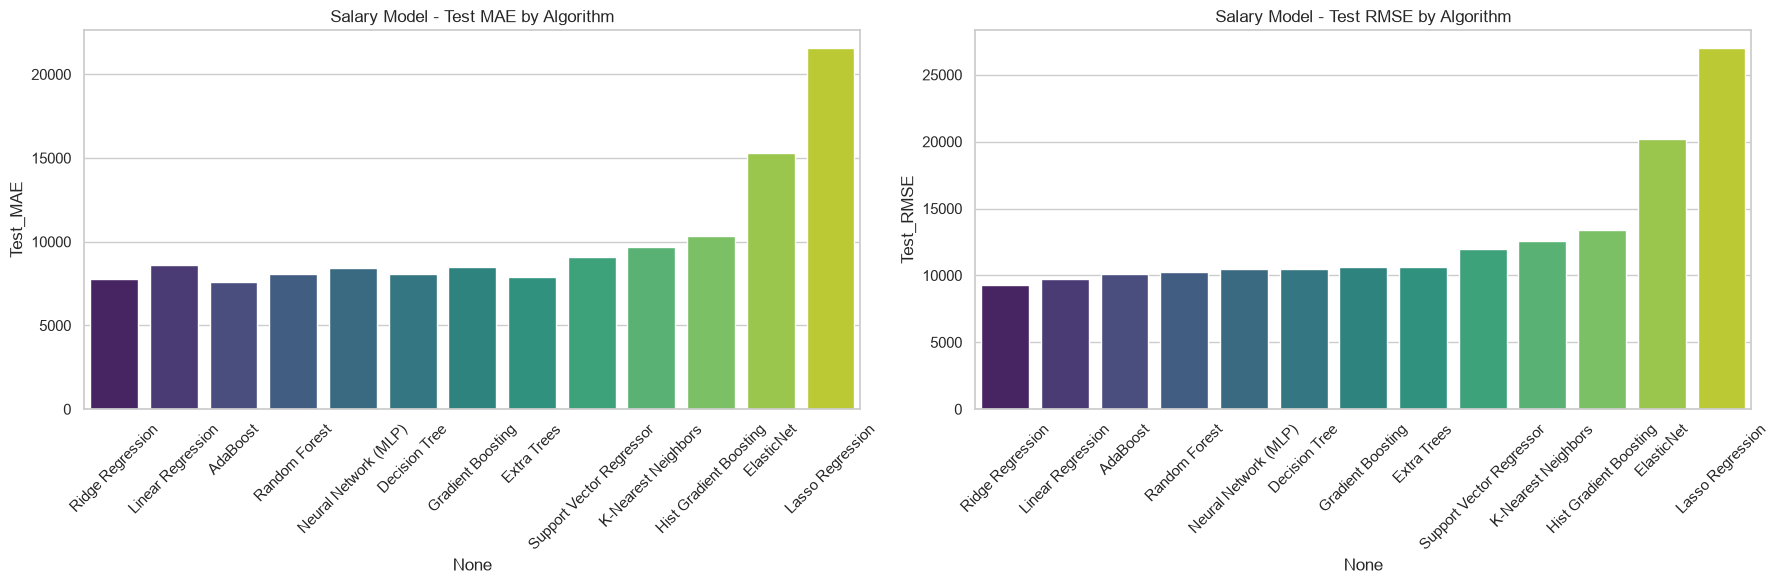

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=plain_results_df.index, y=plain_results_df["Test_MAE"], hue=plain_results_df.index, palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Salary Model - Test MAE by Algorithm")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(x=plain_results_df.index, y=plain_results_df["Test_RMSE"], hue=plain_results_df.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Salary Model - Test RMSE by Algorithm")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [21]:
best_plain_name = plain_results_df.index[0]
best_plain_pipeline = make_estimator(PLAIN_CAT, PLAIN_NUM, get_models()[best_plain_name])
best_plain_pipeline.fit(salary_df[PLAIN_CAT + PLAIN_NUM], salary_df["Monthly_Salary"])

Path("models").mkdir(exist_ok=True)
joblib.dump(best_plain_pipeline, "models/salary_model.pkl")

print("Production salary model:", best_plain_name)
print(plain_results_df.loc[best_plain_name])

Production salary model: Ridge Regression
CV_R2_Mean       0.882888
Test_R2          0.879412
Test_MAE      7770.784699
Test_RMSE     9308.367262
Name: Ridge Regression, dtype: float64


In [22]:
enriched_salary_results = {}
enriched_salary_fitted = {}
for name, model in get_models().items():
    evaluate(name, model, combined_train, combined_test, ENRICHED_SALARY_CAT, ENRICHED_SALARY_NUM, "Monthly_Salary", enriched_salary_results, enriched_salary_fitted)

Linear Regression {'CV_R2_Mean': 0.9327732968841603, 'Test_R2': 0.94526796415212, 'Test_MAE': 5010.109151941133, 'Test_RMSE': 6208.314025719266}
Ridge Regression {'CV_R2_Mean': 0.9330358084908511, 'Test_R2': 0.9465605353427118, 'Test_MAE': 4965.194678013546, 'Test_RMSE': 6134.567141960168}


Lasso Regression {'CV_R2_Mean': -0.01054797861548229, 'Test_R2': -0.008221967283394083, 'Test_MAE': 22635.8625, 'Test_RMSE': 26645.93428766385}


ElasticNet {'CV_R2_Mean': 0.44733001255410015, 'Test_R2': 0.44967167446793876, 'Test_MAE': 16742.36015718626, 'Test_RMSE': 19686.28680754735}
Decision Tree {'CV_R2_Mean': 0.9925141949467697, 'Test_R2': 0.9989633859025666, 'Test_MAE': 70.00000000000058, 'Test_RMSE': 854.4003745317531}


Random Forest {'CV_R2_Mean': 0.9963468826640796, 'Test_R2': 0.9982258946130538, 'Test_MAE': 357.60000000000554, 'Test_RMSE': 1117.7446041023827}


Extra Trees {'CV_R2_Mean': 0.9999596277343421, 'Test_R2': 0.9999896173513012, 'Test_MAE': 25.52500000005126, 'Test_RMSE': 85.50804055760202}


AdaBoost {'CV_R2_Mean': 0.92864620491388, 'Test_R2': 0.9409063269075125, 'Test_MAE': 5466.3950600875805, 'Test_RMSE': 6450.9454186516505}


Gradient Boosting {'CV_R2_Mean': 0.9866101176478839, 'Test_R2': 0.9900564496652892, 'Test_MAE': 1915.9963195895573, 'Test_RMSE': 2646.205775295996}


Hist Gradient Boosting {'CV_R2_Mean': 0.9937654080496998, 'Test_R2': 0.9982629059571962, 'Test_MAE': 768.6884861517111, 'Test_RMSE': 1106.0239724350242}
K-Nearest Neighbors {'CV_R2_Mean': 0.9722670684227349, 'Test_R2': 0.9814588078490574, 'Test_MAE': 2203.0, 'Test_RMSE': 3613.4471076798677}


Support Vector Regressor {'CV_R2_Mean': 0.9831862726689862, 'Test_R2': 0.9885281467574499, 'Test_MAE': 2541.0665309784804, 'Test_RMSE': 2842.2983696101796}


Neural Network (MLP) {'CV_R2_Mean': 0.9826190982479008, 'Test_R2': 0.984452552824523, 'Test_MAE': 2610.672339012939, 'Test_RMSE': 3308.8906844968556}


In [23]:
enriched_salary_df = pd.DataFrame(enriched_salary_results).T.sort_values("Test_R2", ascending=False)
enriched_salary_df

,CV_R2_Mean,Test_R2,Test_MAE,Test_RMSE
Extra Trees,0.999960,0.999990,25.525000,85.508041
Decision Tree,0.992514,0.998963,70.000000,854.400375
Hist Gradient Boosting,0.993765,0.998263,768.688486,1106.023972
Random Forest,0.996347,0.998226,357.600000,1117.744604
Gradient Boosting,0.986610,0.990056,1915.996320,2646.205775
Support Vector Regressor,0.983186,0.988528,2541.066531,2842.298370
Neural Network (MLP),0.982619,0.984453,2610.672339,3308.890684
K-Nearest Neighbors,0.972267,0.981459,2203.000000,3613.447108
Ridge Regression,0.933036,0.946561,4965.194678,6134.567142
Linear Regression,0.932773,0.945268,5010.109152,6208.314026


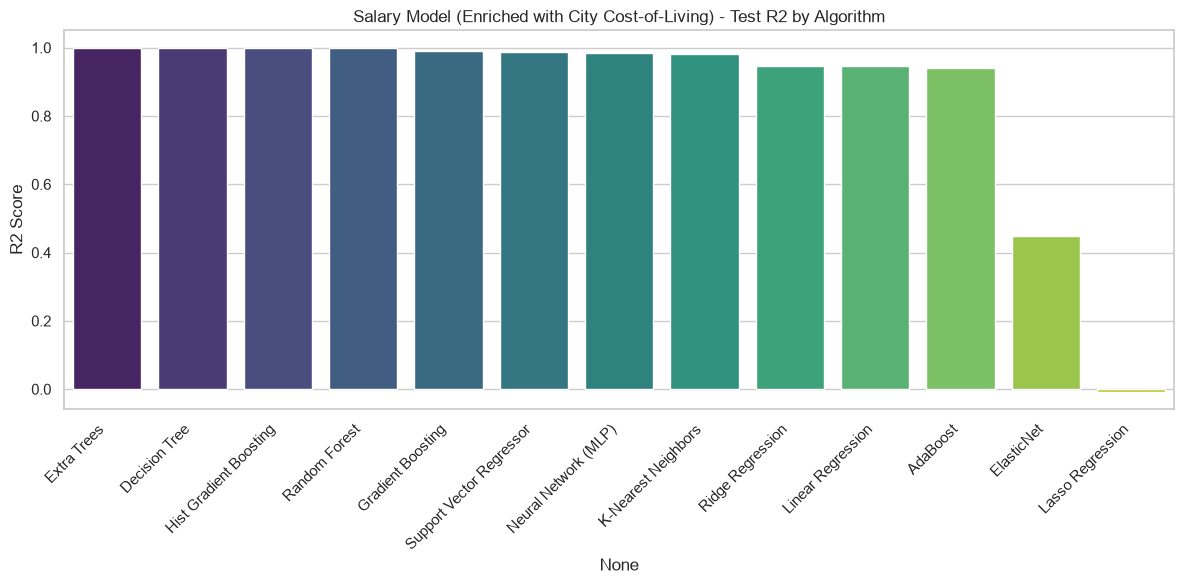

Best plain salary R2: 0.8794121295450564
Best enriched salary R2: 0.9999896173513012


In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(x=enriched_salary_df.index, y=enriched_salary_df["Test_R2"], hue=enriched_salary_df.index, palette="viridis", legend=False)
plt.title("Salary Model (Enriched with City Cost-of-Living) - Test R2 by Algorithm")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Best plain salary R2:", plain_results_df["Test_R2"].max())
print("Best enriched salary R2:", enriched_salary_df["Test_R2"].max())

In [25]:
marriage_results = {}
marriage_fitted = {}
for name, model in get_models().items():
    evaluate(name, model, combined_train, combined_test, COST_CAT, COST_NUM["Marriage_Cost_Current"], "Marriage_Cost_Current", marriage_results, marriage_fitted)

Linear Regression {'CV_R2_Mean': 0.9991102234374182, 'Test_R2': 0.9991732881897384, 'Test_MAE': 3573.1598030216687, 'Test_RMSE': 4402.170898498348}
Ridge Regression {'CV_R2_Mean': 0.9989835403490019, 'Test_R2': 0.9990959845225447, 'Test_MAE': 3555.1022587757675, 'Test_RMSE': 4603.3898998424365}
Lasso Regression {'CV_R2_Mean': -0.010258570371913356, 'Test_R2': -0.011737678686534192, 'Test_MAE': 125875.625, 'Test_RMSE': 154001.08816579837}


ElasticNet {'CV_R2_Mean': 0.55854128913361, 'Test_R2': 0.5773104861483505, 'Test_MAE': 83912.11996993535, 'Test_RMSE': 99540.67111087884}
Decision Tree {'CV_R2_Mean': 0.9999952162265595, 'Test_R2': 1.0, 'Test_MAE': 1.7462298274040222e-12, 'Test_RMSE': 1.008186260918666e-11}


Random Forest {'CV_R2_Mean': 0.9999497364166323, 'Test_R2': 0.9999868090101228, 'Test_MAE': 232.75000000016414, 'Test_RMSE': 556.0687907085571}


Extra Trees {'CV_R2_Mean': 0.9999996205466152, 'Test_R2': 1.0, 'Test_MAE': 3.073364496231079e-10, 'Test_RMSE': 4.4405998482277273e-10}


AdaBoost {'CV_R2_Mean': 0.9815196198591718, 'Test_R2': 0.9849736549908953, 'Test_MAE': 15506.844064348801, 'Test_RMSE': 18767.93564471001}


Gradient Boosting {'CV_R2_Mean': 0.9995333657974845, 'Test_R2': 0.9996321889731411, 'Test_MAE': 2417.226632959133, 'Test_RMSE': 2936.3120005704227}


Hist Gradient Boosting {'CV_R2_Mean': 0.9992614755903537, 'Test_R2': 0.9993507830098552, 'Test_MAE': 1643.6383980773235, 'Test_RMSE': 3901.079186226705}
K-Nearest Neighbors {'CV_R2_Mean': 0.9308829748043056, 'Test_R2': 0.9374246785252797, 'Test_MAE': 28440.0, 'Test_RMSE': 38299.34725292325}


Support Vector Regressor {'CV_R2_Mean': 0.9914440840105417, 'Test_R2': 0.9937070375581555, 'Test_MAE': 10251.844349941459, 'Test_RMSE': 12145.555905850559}


Neural Network (MLP) {'CV_R2_Mean': 0.990955481615237, 'Test_R2': 0.9916781143593384, 'Test_MAE': 11260.292911692173, 'Test_RMSE': 13966.921724597063}


In [26]:
marriage_results_df = pd.DataFrame(marriage_results).T.sort_values("Test_R2", ascending=False)
marriage_results_df

,CV_R2_Mean,Test_R2,Test_MAE,Test_RMSE
Decision Tree,0.999995,1.000000,1.746230e-12,1.008186e-11
Extra Trees,1.000000,1.000000,3.073364e-10,4.440600e-10
Random Forest,0.999950,0.999987,2.327500e+02,5.560688e+02
Gradient Boosting,0.999533,0.999632,2.417227e+03,2.936312e+03
Hist Gradient Boosting,0.999261,0.999351,1.643638e+03,3.901079e+03
Linear Regression,0.999110,0.999173,3.573160e+03,4.402171e+03
Ridge Regression,0.998984,0.999096,3.555102e+03,4.603390e+03
Support Vector Regressor,0.991444,0.993707,1.025184e+04,1.214556e+04
Neural Network (MLP),0.990955,0.991678,1.126029e+04,1.396692e+04
AdaBoost,0.981520,0.984974,1.550684e+04,1.876794e+04


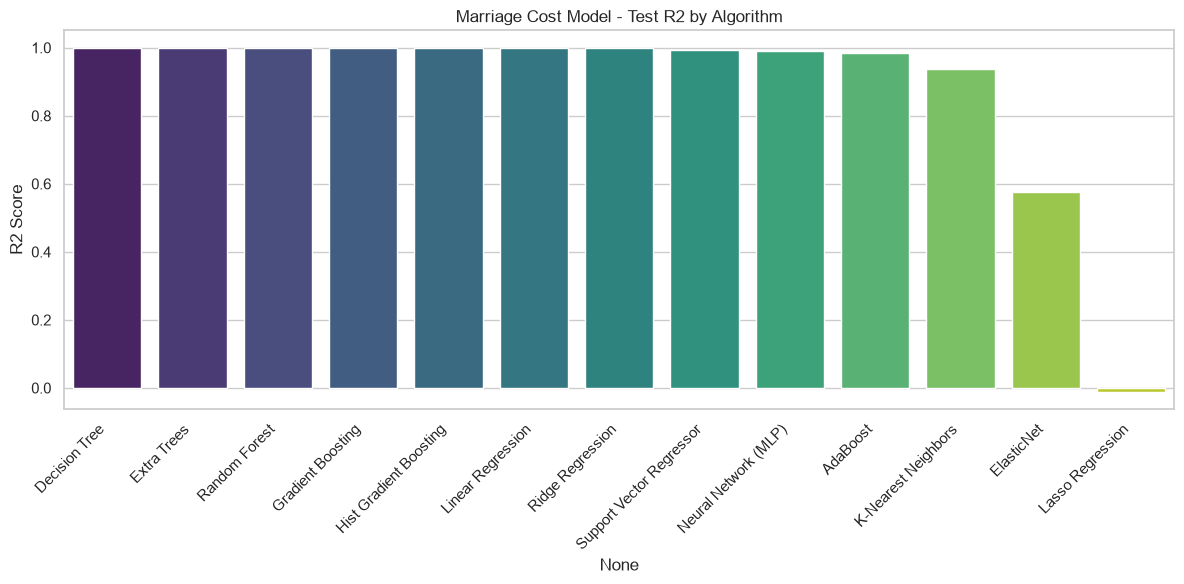

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(x=marriage_results_df.index, y=marriage_results_df["Test_R2"], hue=marriage_results_df.index, palette="viridis", legend=False)
plt.title("Marriage Cost Model - Test R2 by Algorithm")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [28]:
car_results = {}
car_fitted = {}
for name, model in get_models().items():
    evaluate(name, model, combined_train, combined_test, COST_CAT, COST_NUM["Car_Cost_Current"], "Car_Cost_Current", car_results, car_fitted)

Linear Regression {'CV_R2_Mean': 0.9995729917838897, 'Test_R2': 0.9996032727402767, 'Test_MAE': 2636.6934205070825, 'Test_RMSE': 3391.395527896427}
Ridge Regression {'CV_R2_Mean': 0.9995525410244686, 'Test_R2': 0.9996082886302607, 'Test_MAE': 2642.2220969892105, 'Test_RMSE': 3369.888337669433}
Lasso Regression {'CV_R2_Mean': -0.009488286854504712, 'Test_R2': -0.003712883880610196, 'Test_MAE': 131675.5, 'Test_RMSE': 170583.55907003465}
ElasticNet {'CV_R2_Mean': 0.5722726920085609, 'Test_R2': 0.5721696580004489, 'Test_MAE': 85862.14619638969, 'Test_RMSE': 111369.99823222862}


Decision Tree {'CV_R2_Mean': 1.0, 'Test_R2': 1.0, 'Test_MAE': 0.0, 'Test_RMSE': 0.0}


Random Forest {'CV_R2_Mean': 0.9998174238981099, 'Test_R2': 0.9999695811923034, 'Test_MAE': 337.50000000000756, 'Test_RMSE': 939.0819985496134}


Extra Trees {'CV_R2_Mean': 0.9999996405277708, 'Test_R2': 1.0, 'Test_MAE': 3.0209776014089587e-10, 'Test_RMSE': 5.294657913626557e-10}


AdaBoost {'CV_R2_Mean': 0.9706202697089104, 'Test_R2': 0.9719796707839329, 'Test_MAE': 24457.537398925753, 'Test_RMSE': 28501.586737218964}


Gradient Boosting {'CV_R2_Mean': 0.9992492168377801, 'Test_R2': 0.9992940824717242, 'Test_MAE': 3429.06475752577, 'Test_RMSE': 4523.862587786106}


Hist Gradient Boosting {'CV_R2_Mean': 0.998435525568835, 'Test_R2': 0.9985835816354985, 'Test_MAE': 2767.393533391083, 'Test_RMSE': 6408.084004699139}
K-Nearest Neighbors {'CV_R2_Mean': 0.8329347234847477, 'Test_R2': 0.86613758493552, 'Test_MAE': 47050.0, 'Test_RMSE': 62296.22781517353}


Support Vector Regressor {'CV_R2_Mean': 0.9891312400482153, 'Test_R2': 0.9930487311306111, 'Test_MAE': 12523.357013796647, 'Test_RMSE': 14195.950141925297}


Neural Network (MLP) {'CV_R2_Mean': 0.9909736640633764, 'Test_R2': 0.9909098956491793, 'Test_MAE': 12773.009952952276, 'Test_RMSE': 16233.675343129207}


In [29]:
car_results_df = pd.DataFrame(car_results).T.sort_values("Test_R2", ascending=False)
car_results_df

,CV_R2_Mean,Test_R2,Test_MAE,Test_RMSE
Decision Tree,1.000000,1.000000,0.000000e+00,0.000000e+00
Extra Trees,1.000000,1.000000,3.020978e-10,5.294658e-10
Random Forest,0.999817,0.999970,3.375000e+02,9.390820e+02
Ridge Regression,0.999553,0.999608,2.642222e+03,3.369888e+03
Linear Regression,0.999573,0.999603,2.636693e+03,3.391396e+03
Gradient Boosting,0.999249,0.999294,3.429065e+03,4.523863e+03
Hist Gradient Boosting,0.998436,0.998584,2.767394e+03,6.408084e+03
Support Vector Regressor,0.989131,0.993049,1.252336e+04,1.419595e+04
Neural Network (MLP),0.990974,0.990910,1.277301e+04,1.623368e+04
AdaBoost,0.970620,0.971980,2.445754e+04,2.850159e+04


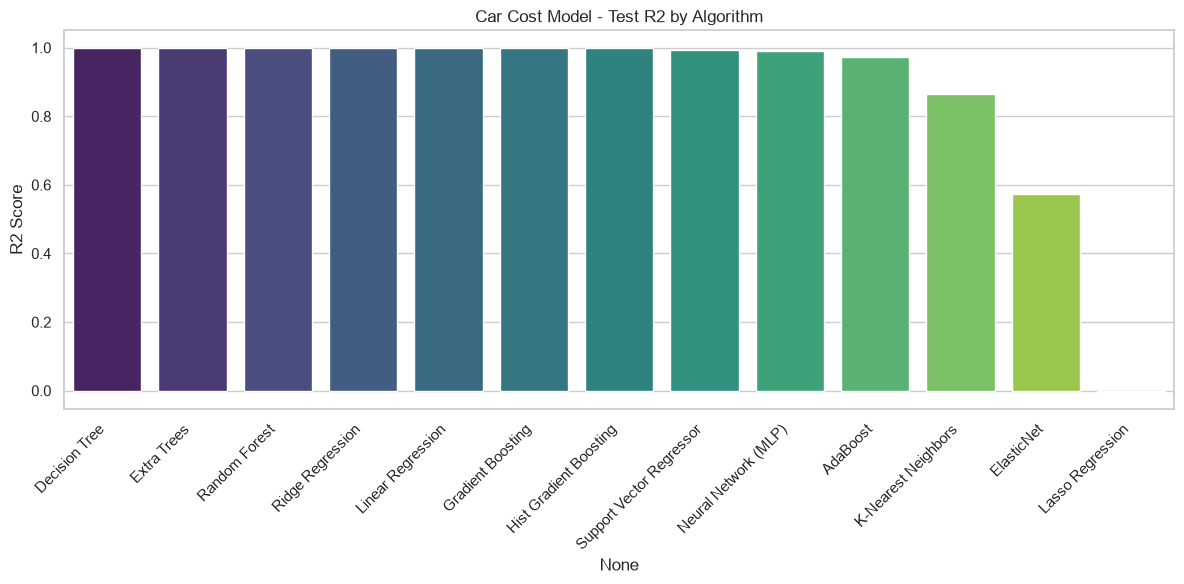

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(x=car_results_df.index, y=car_results_df["Test_R2"], hue=car_results_df.index, palette="viridis", legend=False)
plt.title("Car Cost Model - Test R2 by Algorithm")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [31]:
home_results = {}
home_fitted = {}
for name, model in get_models().items():
    evaluate(name, model, combined_train, combined_test, COST_CAT, COST_NUM["Home_Cost_Current"], "Home_Cost_Current", home_results, home_fitted)

Linear Regression {'CV_R2_Mean': 0.9991125516436755, 'Test_R2': 0.9992003447974945, 'Test_MAE': 50373.74053948985, 'Test_RMSE': 65594.01652639122}
Ridge Regression {'CV_R2_Mean': 0.9989259009828423, 'Test_R2': 0.9990350694034414, 'Test_MAE': 54793.55377469151, 'Test_RMSE': 72054.46204721247}
Lasso Regression {'CV_R2_Mean': -0.007984660957438106, 'Test_R2': -0.007564868864640806, 'Test_MAE': 1711870.0, 'Test_RMSE': 2328355.817417089}
ElasticNet {'CV_R2_Mean': 0.5405157440150052, 'Test_R2': 0.5364485935811063, 'Test_MAE': 1089815.8699738774, 'Test_RMSE': 1579289.6635204228}


Decision Tree {'CV_R2_Mean': 0.9999637806621984, 'Test_R2': 1.0, 'Test_MAE': 2.3283064365386964e-11, 'Test_RMSE': 1.6789656483866226e-10}


Random Forest {'CV_R2_Mean': 0.9997449022896362, 'Test_R2': 0.999877995001522, 'Test_MAE': 6120.000000001918, 'Test_RMSE': 25621.329005341955}


Extra Trees {'CV_R2_Mean': 0.9999976081675774, 'Test_R2': 1.0, 'Test_MAE': 4.163011908531189e-09, 'Test_RMSE': 6.2663892540345756e-09}


AdaBoost {'CV_R2_Mean': 0.9642525525792918, 'Test_R2': 0.970769851257926, 'Test_MAE': 360366.2305137767, 'Test_RMSE': 396577.75876219315}


Gradient Boosting {'CV_R2_Mean': 0.9993786356338459, 'Test_R2': 0.9995508175756015, 'Test_MAE': 38254.61871678644, 'Test_RMSE': 49161.39736737066}


Hist Gradient Boosting {'CV_R2_Mean': 0.9989364620314649, 'Test_R2': 0.9991917196469098, 'Test_MAE': 29696.981897676542, 'Test_RMSE': 65946.8191225739}
K-Nearest Neighbors {'CV_R2_Mean': 0.9704222198825534, 'Test_R2': 0.978048662515192, 'Test_MAE': 257100.0, 'Test_RMSE': 343671.3546398652}


Support Vector Regressor {'CV_R2_Mean': 0.9902749277908282, 'Test_R2': 0.9930564432353842, 'Test_MAE': 166125.77980069353, 'Test_RMSE': 193287.5300977354}


Neural Network (MLP) {'CV_R2_Mean': 0.9911489180037941, 'Test_R2': 0.9920805979744878, 'Test_MAE': 164476.04484828265, 'Test_RMSE': 206423.4520486829}


In [32]:
home_results_df = pd.DataFrame(home_results).T.sort_values("Test_R2", ascending=False)
home_results_df

,CV_R2_Mean,Test_R2,Test_MAE,Test_RMSE
Decision Tree,0.999964,1.000000,2.328306e-11,1.678966e-10
Extra Trees,0.999998,1.000000,4.163012e-09,6.266389e-09
Random Forest,0.999745,0.999878,6.120000e+03,2.562133e+04
Gradient Boosting,0.999379,0.999551,3.825462e+04,4.916140e+04
Linear Regression,0.999113,0.999200,5.037374e+04,6.559402e+04
Hist Gradient Boosting,0.998936,0.999192,2.969698e+04,6.594682e+04
Ridge Regression,0.998926,0.999035,5.479355e+04,7.205446e+04
Support Vector Regressor,0.990275,0.993056,1.661258e+05,1.932875e+05
Neural Network (MLP),0.991149,0.992081,1.644760e+05,2.064235e+05
K-Nearest Neighbors,0.970422,0.978049,2.571000e+05,3.436714e+05


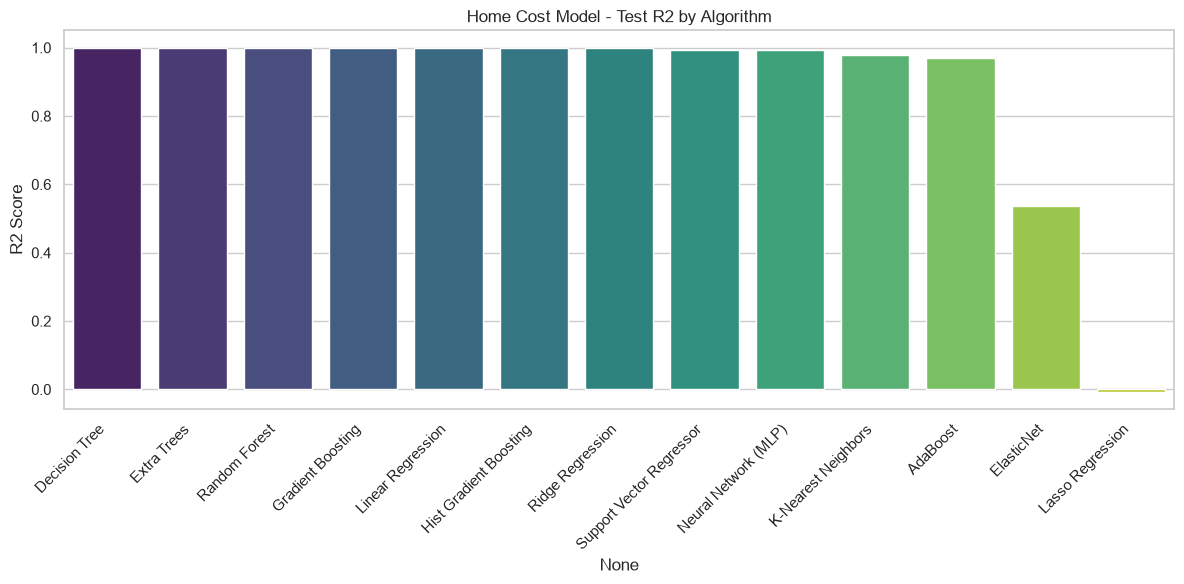

In [33]:
plt.figure(figsize=(12, 6))
sns.barplot(x=home_results_df.index, y=home_results_df["Test_R2"], hue=home_results_df.index, palette="viridis", legend=False)
plt.title("Home Cost Model - Test R2 by Algorithm")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
summary = pd.DataFrame({
    "Best_Algorithm": [
        plain_results_df.index[0],
        enriched_salary_df.index[0],
        marriage_results_df.index[0],
        car_results_df.index[0],
        home_results_df.index[0],
    ],
    "Best_Test_R2": [
        plain_results_df["Test_R2"].max(),
        enriched_salary_df["Test_R2"].max(),
        marriage_results_df["Test_R2"].max(),
        car_results_df["Test_R2"].max(),
        home_results_df["Test_R2"].max(),
    ],
}, index=["Salary (Plain)", "Salary (Enriched)", "Marriage Cost", "Car Cost", "Home Cost"])

print(summary)
print("Saved production model: models/salary_model.pkl ->", best_plain_name)
print("Marriage/Car/Home cost R2 near 1.0 reflects City+Area_Type deterministically fixing those costs in the source table, not a discovered pattern beyond the lookup itself.")

                     Best_Algorithm  Best_Test_R2
Salary (Plain)     Ridge Regression      0.879412
Salary (Enriched)       Extra Trees      0.999990
Marriage Cost         Decision Tree      1.000000
Car Cost              Decision Tree      1.000000
Home Cost             Decision Tree      1.000000
Saved production model: models/salary_model.pkl -> Ridge Regression
Marriage/Car/Home cost R2 near 1.0 reflects City+Area_Type deterministically fixing those costs in the source table, not a discovered pattern beyond the lookup itself.
